# Regime switching on the carry book

A carry book spends most of its life being boring. The interest differential accrues, the spot
rates wander, and the monthly return lands somewhere near a percent. Then, every few years,
every position turns over at once and the book gives back two years of accrual in a quarter.
The 27-currency book underneath this notebook has a monthly return skew of about $-0.65$ and a
worst drawdown near 29%. That asymmetry is the whole reason carry pays anything: you are being
compensated for holding a position that occasionally detonates.

It also makes regime switching almost impossible to resist. If the bad months arrive in
clusters, and if something observable marks the clusters while they are happening, then a
model that recognises the cluster and stands aside should collect the accrual without the
detonation. The literature is full of versions of this, most of them reporting that it works.

What follows is an attempt to find out whether it works here, under the constraint that
matters most and is easiest to break: at every date, the model may only use what a person
sitting at that date could have known. That turns out to be the entire story. Five different
regime models, spanning latent-state estimators, a rule on an observable, and a supervised
classifier, all improve the book when they are allowed a peek at the future, and all fail to
improve it when they are not.

This notebook needs two repositories side by side. The estimators come from `fxcarry`, and the
book, the raw panels and the data plumbing come from the team project `FX_Carry_26_Summer_PL`.
The setup cell below finds both from wherever it is being run, so the same file executes
unchanged out of either checkout. Point `FX_CARRY_PL_ROOT` at the team repository if it does
not sit beside this one.

## The book everything is measured against

Every variant here differs from one shared baseline by exactly one thing: a monthly exposure
multiplier. The baseline is the project's team book, and using it rather than building another
one is deliberate. A gate measured against its author's own private construction tells you
nothing about the gate, only about the pair.

The base is a quintile sort on forward-implied carry across 27 currencies, inverse-volatility
weighted within each leg, targeted to 10% annualised volatility, rebalanced monthly, and
charged real bid/ask half-spreads with maintained notional rolled at the points spread. It
runs from May 2007 to June 2026. Its net Sharpe is 0.4659 against 0.6284 gross, so roughly a
sixth of a Sharpe point is eaten by costs before any overlay exists.

The exposure hook matters more than it looks. It scales *weights*, not returns, which means a
gate pays the transaction costs of the trades it triggers. Applying a multiplier to a finished
return series instead is free, and free de-risking makes every risk rule look better than it
is.

In [1]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")


def locate_repositories():
    # Both checkouts, found from the working directory rather than assumed. The team project
    # holds the base strategy, the raw panels and the `regime_lab` plumbing; the library holds
    # the estimators. Whichever library checkout this notebook is sitting inside wins, so
    # running the copy in fxcarry tests fxcarry's own source.
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]

    override = os.environ.get("FX_CARRY_PL_ROOT")
    team = Path(override).resolve() if override else None
    if team is None:
        team = next((p for p in candidates if (p / "strategy" / "core.py").is_file()), None)
    if team is None:
        for parent in candidates:
            guess = parent / "FX_Carry_26_Summer_PL"
            if (guess / "strategy" / "core.py").is_file():
                team = guess.resolve()
                break
    if team is None:
        raise RuntimeError(
            "Could not find FX_Carry_26_Summer_PL. Put it beside this repository, or set "
            "FX_CARRY_PL_ROOT to its path."
        )

    library = next(
        (p / "src" for p in candidates if (p / "src" / "fxcarry" / "__init__.py").is_file()),
        None,
    )
    if library is None:
        library = team / "dafu" / "fxcarry" / "src"
    if not (library / "fxcarry" / "__init__.py").is_file():
        raise RuntimeError(f"No fxcarry source at {library}.")
    return team, library.resolve()


TEAM, LIBRARY = locate_repositories()
for path in (TEAM, LIBRARY, TEAM / "dafu"):
    sys.path.insert(0, str(path))

print(f"team project : {TEAM}")
print(f"fxcarry      : {LIBRARY}")

team project : D:\GitHub\summer-26\bofa\repos\FX_Carry_26_Summer_PL
fxcarry      : D:\GitHub\summer-26\bofa\repos\FX_Carry_26_Summer_PL\dafu\fxcarry\src


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fxcarry.compare import Comparison
from fxcarry.regimes import (
    LogisticRegime,
    MarkovSwitching,
    TrailingPercentile,
    binary_gate,
    linear_gate,
    power_gate,
)
from fxcarry.stats import HAC
from strategy import fx_utils as fx, run

import regime_lab as lab

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# Okabe-Ito, the standard colour-blind-safe qualitative set. Assigned in a fixed order and
# never recycled, so a series keeps its colour when the chart it appears in changes.
INK = "#111111"
PALETTE = ["#000000", "#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.labelcolor": INK, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "text.color": INK, "xtick.color": "#666666", "ytick.color": "#666666",
    "grid.color": "#DDDDDD", "grid.linewidth": 0.6, "axes.grid": True,
    "axes.axisbelow": True, "legend.frameon": False, "lines.linewidth": 1.6,
    "font.size": 9.5,
})

# Derived tables land beside whichever copy of the notebook is running, never in the other
# repository.
OUT = Path.cwd() / "outputs"
OUT.mkdir(exist_ok=True)

In [3]:
base = run(name="baseline")
monthly = base.monthly("net")

print(f"universe        {len(base.universe)} currencies")
print(f"window          {base.window[0].date()} to {base.window[1].date()}")
print(f"months          {len(monthly)}")
base.summary(benchmark=None).round(4).T

universe        27 currencies
window          2007-05-01 to 2026-06-30
months          230


,baseline_gross,baseline_net
start,2007-05-01,2007-05-01
end,2026-06-30,2026-06-30
n_days,5001,5001
ann_return,0.07029,0.052143
ann_vol,0.111848,0.111914
daily_variance,0.00005,0.00005
skew,-0.652152,-0.648005
excess_kurtosis,4.579734,4.543499
sharpe,0.628442,0.465923
max_drawdown,-0.267829,-0.293185


## Three ways to answer the same question

Most of the difficulty in this exercise is not estimation. It is that nearly every convenient
way to report a regime probability quietly looks backwards, and the resulting numbers are
better than anything you could have traded.

Take a two-state Markov model fitted to the book's monthly returns. The smoothed probability
for September 2008 is the model's opinion having read every month through 2026. The filtered
probability at that date only reads the past, which sounds fixed, except the parameters
driving the filter were still estimated on the whole sample, so the filter already knows how
volatile the volatile state is going to turn out to be. Only re-estimating the parameters on
an expanding window removes both problems.

`fxcarry.regimes` makes that choice explicit rather than implicit. Every estimator takes an
`information` argument with three values:

`insample` uses the whole sample for parameters and for state inference. Nobody could trade
it. It is here so the size of the illusion can be measured instead of argued about.

`filtered` takes parameters from the whole sample and infers states recursively. This is the
halfway house, and in my experience it is the one that gets published without comment.

`realtime` re-estimates parameters on an expanding window and infers states recursively. At
date $t$ nothing has touched data after $t$.

The module tests this rather than asserting it. Truncating the sample and recomputing must
leave every earlier `realtime` probability bit-identical, and the same check is run against
`insample` and required to *fail*, because a no-lookahead test that passes under every
configuration is not testing anything.

In [4]:
features = lab.build_features(monthly, base.signal)
labels = lab.loss_labels(monthly)
fxvol = lab.fx_volatility()
fxvol_change = np.log(fxvol).diff().dropna().rename("d_log_fx_vol")
equity = lab.month_end(fx.load_wide("global_risk")["MXWO"]).pct_change().dropna()

print(f"conditioning features : {features.shape[1]} series, {features.shape[0]} months")
print(f"losing months         : {int(labels.sum())} of {len(labels)} ({labels.mean():.1%})")
print()
print(features.tail(3).round(3).T.to_string())

conditioning features : 12 series, 228 months
losing months         : 98 of 230 (42.6%)

date                  2026-04-30  2026-05-31  2026-06-30
log_vix                    2.827       2.729       2.800
log_fx_vol                 1.952       1.845       1.892
log_move                   4.278       4.252       4.276
d_log_vix                 -0.402      -0.098       0.071
d_log_fx_vol              -0.165      -0.106       0.046
d_log_move                -0.287      -0.026       0.024
slope_2s10s               49.555      42.731      28.677
financial_conditions       0.903       1.144       1.090
spx_3m                     0.039       0.102       0.149
dxy_3m                     0.011       0.014       0.012
book_vol_3m                0.091       0.092       0.171
carry_dispersion           0.070       0.070       0.064


## Five models, and why the stressed state is named before anything is run

The models differ in what they read and how much structure they assume.

`MS-book` is a two-state Markov switching model on the book's own monthly net return. It is
the textbook version and also the most self-referential: it conditions on the very series it
is trying to protect.

`MS-equity` is the same estimator on world equity monthly returns, which removes the
circularity by looking outside the book entirely.

`MS-fxvol` is the same estimator again on the monthly change in log FX implied volatility.
A carry book is short FX volatility rather than short equity volatility, and the two have
disagreed about which was happening more than once.

`Vol-rank` is not a model at all. It is where FX implied volatility sits in its own trailing
five-year distribution. It exists as the bar the estimators have to clear, because most of
what a regime model knows about a crisis is that volatility was high, and a percentile rank
knows that too.

`Logit` is a ridge logistic regression on twelve macro and market features, trained to predict
whether next month loses money. Standardisation happens inside each fold and the classifier
only ever trains on labels that have already resolved.

There is one decision that has to be made before any of these is run, and getting it wrong
costs more than any tuning parameter. A two-state model does not know which of its states is
the bad one; the likelihood is unchanged if you swap the labels. So the stressed state has to
be identified from the fitted parameters, and the rule has to come from what the series *is*.
For a profit and loss series the bad state is the one that loses money. For a series of
volatility changes it is the one where volatility jumps. Picking the rule that backtests best
is a second helping of exactly the hindsight this whole exercise is trying to measure, and
there is a section below showing what that costs.

In [5]:
SPECS = {
    "MS-book":   dict(kind="markov", data=monthly,      stressed="low_mean",
                      sets=("insample", "filtered", "realtime")),
    "MS-equity": dict(kind="markov", data=equity,       stressed="low_mean",
                      sets=("insample", "filtered", "realtime")),
    "MS-fxvol":  dict(kind="markov", data=fxvol_change, stressed="high_mean",
                      sets=("insample", "filtered", "realtime")),
    "Vol-rank":  dict(kind="percentile", data=fxvol,    sets=("insample", "realtime")),
    "Logit":     dict(kind="logit", data=features,      sets=("insample", "realtime")),
}


def model_for(label, spec, information):
    # The estimator for one model under one information set.
    if spec["kind"] == "markov":
        return MarkovSwitching(information=information, stressed=spec["stressed"],
                               min_periods=60, refit_every=12, name=f"{label} [{information}]")
    if spec["kind"] == "percentile":
        return TrailingPercentile(information=information, window=60, min_periods=36,
                                  name=f"{label} [{information}]")
    return LogisticRegime(labels, information=information, ridge=1.0, min_periods=60,
                          refit_every=3, name=f"{label} [{information}]")


paths = {}
for label, spec in SPECS.items():
    for information in spec["sets"]:
        paths[(label, information)] = model_for(label, spec, information).probabilities(spec["data"])
    print(f"{label:10s} " + "  ".join(
        f"{i}: {paths[(label, i)].stressed_share:.3f}" for i in spec["sets"]))

MS-book    insample: 0.032  filtered: 0.028  realtime: 0.169


MS-equity  insample: 0.494  filtered: 0.494  realtime: 0.395


MS-fxvol   insample: 0.022  filtered: 0.022  realtime: 0.009
Vol-rank   insample: 0.502  realtime: 0.409


Logit      insample: 0.434  realtime: 0.446


## What the switching models actually found

Before trusting a probability path it is worth looking at the states behind it. The table below
reports the last fitted parameter set for each Markov model in per-month percent, alongside the
persistence of each state.

Two things stand out. On the book's own returns the full-sample fit separates a normal state
averaging $+0.74\%$ a month from a crash state averaging $-8.2\%$, and the crash state is
transient: once in it, the model expects to leave with probability 0.67 the following month.
That is a sensible description of a carry unwind. The standard deviations of the two states,
however, are 2.91% and 3.42%, barely different. The states here are separated by their means,
not their variances, which is precisely why identifying the stressed state by variance is the
wrong call on this series.

On FX volatility changes the separation is enormous and in the other direction: a quiet state
drifting at $-0.79\%$ a month against a spike state averaging $+34\%$. That model knows exactly
what it is looking for. Whether the book cares is a different question.

In [6]:
fitted = {}
for label, spec in SPECS.items():
    if spec["kind"] != "markov":
        continue
    for information in ("insample", "realtime"):
        row = paths[(label, information)].parameters.iloc[-1]
        fitted[(label, information)] = {
            "mean_0_%": 100 * row["const[0]"], "sd_0_%": 100 * np.sqrt(row["sigma2[0]"]),
            "mean_1_%": 100 * row["const[1]"], "sd_1_%": 100 * np.sqrt(row["sigma2[1]"]),
            "P(stay in 0)": row["p[0->0]"], "P(leave 1)": row["p[1->0]"],
            "refits": len(paths[(label, information)].parameters),
        }

fitted = pd.DataFrame(fitted).T
fitted.index = pd.MultiIndex.from_tuples(fitted.index, names=["model", "information"])
fitted.round(3)

mean_0_%  sd_0_%  mean_1_%  sd_1_%  P(stay in 0)  P(leave 1)  refits
model     information                                                                      
MS-book   insample        0.736   2.907    -8.217   3.423         0.978       0.674     1.0
          realtime       -0.299   1.455     0.610   3.615         0.000       0.290    15.0
MS-equity insample        1.312   2.369    -0.108   5.987         0.902       0.101     1.0
          realtime        1.297   2.387    -0.150   5.983         0.920       0.090    15.0
MS-fxvol  insample       -0.790   8.872    34.045  10.925         0.986       0.620     1.0
          realtime       -0.758   8.795    33.537  11.045         0.985       0.632    15.0

## Nobody is armed for the crisis

The next table is the one that reframed this project for me. It reports the first date each
model produces a probability at all.

A Markov switching model needs a few years of monthly data before its parameters mean
anything, and the shared panel begins in 2007. Five years of burn-in therefore puts the first
honest `realtime` probability in 2012. The models fitted on the whole sample, by contrast,
start producing opinions in early 2007, because they were estimated on data that includes
everything they are opining about.

The consequence is blunt. Not one of the real-time models was operating during the 2008
unwind, which is the largest carry drawdown in the sample and the event the entire idea of a
crisis gate exists to handle. They arm somewhere between 2010 and 2012 and are then evaluated
on a period whose worst episode is COVID. Anyone reporting a regime gate that "would have
avoided 2008" on a panel starting in 2007 has fitted the model on 2008 and then tested it on
2008.

This is a data problem before it is a modelling problem, and it has a price tag: risk-factor
history reaching back to the 1990s would let a model be armed *for* a crisis rather than
calibrated *after* one.

In [7]:
activity = {}
for (label, information), series in paths.items():
    prob = series.probability
    activity[f"{label} [{information}]"] = {
        "armed from": str(prob.index[0].date()),
        "months": len(prob),
        "mean P(stress)": prob.mean(),
        "months P>0.5": float((prob > 0.5).mean()),
        "months P>0.9": float((prob > 0.9).mean()),
    }
pd.DataFrame(activity).T

,armed from,months,mean P(stress),months P>0.5,months P>0.9
MS-book [insample],2007-05-31,230,0.031692,0.030435,0.013043
MS-book [filtered],2007-05-31,230,0.027798,0.021739,0.013043
MS-book [realtime],2012-05-31,170,0.168803,0.094118,0.0
MS-equity [insample],2007-02-28,233,0.494474,0.48927,0.257511
MS-equity [filtered],2007-02-28,233,0.49442,0.446352,0.2103
MS-equity [realtime],2012-02-29,173,0.395256,0.358382,0.156069
MS-fxvol [insample],2007-02-28,233,0.022473,0.017167,0.017167
MS-fxvol [filtered],2007-02-28,233,0.021831,0.012876,0.012876
MS-fxvol [realtime],2012-02-29,173,0.00927,0.00578,0.00578
Vol-rank [insample],2007-01-31,234,0.502137,0.5,0.102564


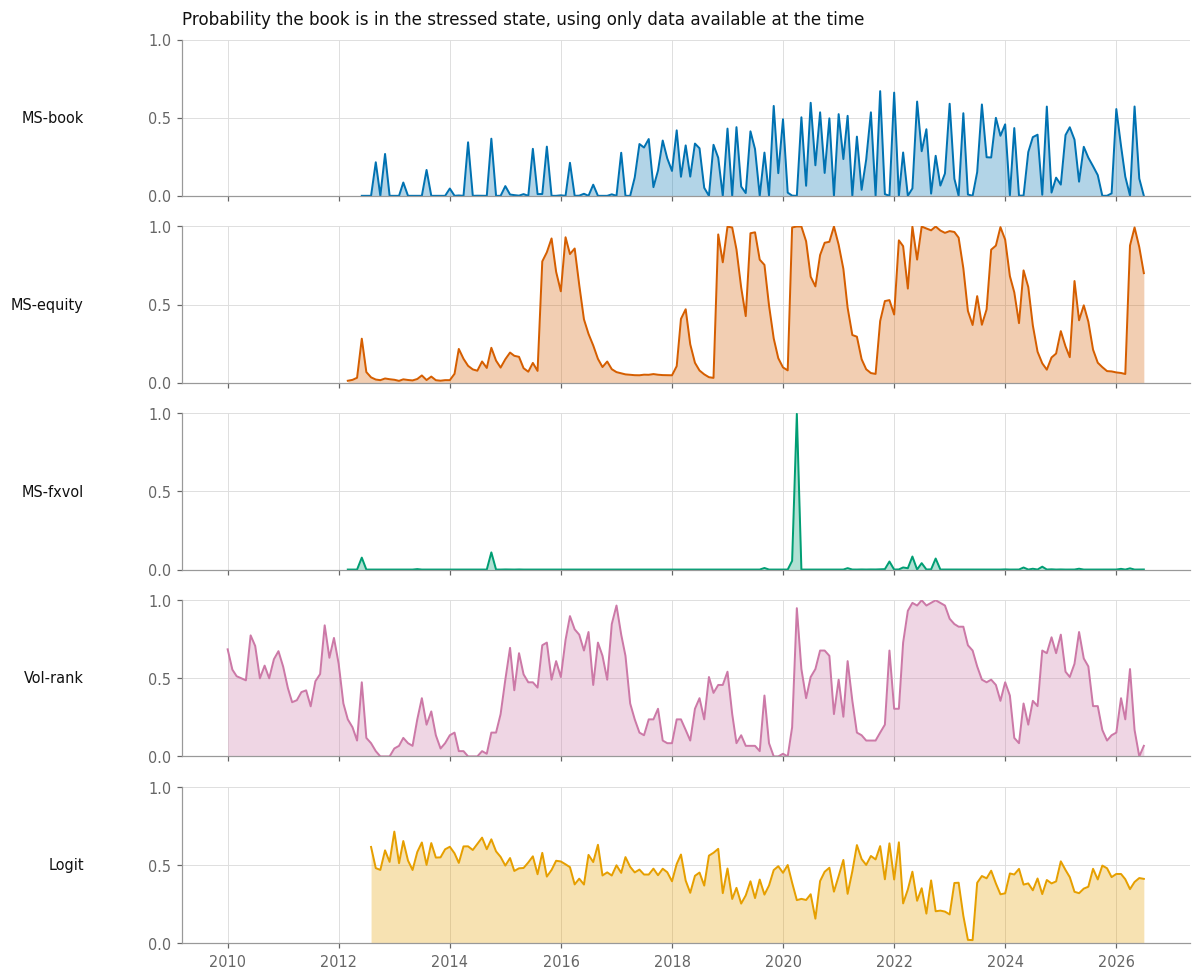

In [8]:
realtime_probs = pd.DataFrame({k: paths[(k, "realtime")].probability for k in SPECS}).dropna()

fig, axes = plt.subplots(len(SPECS), 1, figsize=(11, 9), sharex=True)
for ax, (label, colour) in zip(axes, zip(SPECS, PALETTE[1:])):
    series = paths[(label, "realtime")].probability
    ax.fill_between(series.index, 0, series.values, color=colour, alpha=0.30, lw=0)
    ax.plot(series.index, series.values, color=colour, lw=1.3)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", labelpad=42)
axes[0].set_title("Probability the book is in the stressed state, using only data available at the time")
axes[-1].set_xlabel("")
fig.tight_layout()
plt.show()

Those five paths are supposed to be measuring the same thing. They are not. `MS-fxvol` fires on
0.9% of months and is close to a no-op; `MS-equity` and `Vol-rank` sit near 40%; `Logit`
hovers around a coin flip without ever committing past 0.9.

Their correlations make the disagreement precise. The largest positive pairing is `MS-equity`
with `Vol-rank` at 0.46, which is unsurprising since equity drawdowns and volatility spikes
are close cousins. `Logit` is *negatively* correlated with both, around $-0.5$ and $-0.42$.
The supervised model, having been told what a bad outcome looks like, has concluded that
something other than high volatility predicts it.

I do not think that is a bug. It is a warning that "regime" is not one thing. These models are
answering different questions and there is no reason their answers should agree, which also
means picking the one whose answer you like is a choice with consequences.

In [9]:
agreement = realtime_probs.corr()
print(f"overlapping window: {realtime_probs.index[0].date()} to {realtime_probs.index[-1].date()}"
      f"  ({len(realtime_probs)} months)")
agreement.round(3)

overlapping window: 2012-07-31 to 2026-06-30  (168 months)


,MS-book,MS-equity,MS-fxvol,Vol-rank,Logit
MS-book,1.000,0.214,-0.066,0.039,-0.224
MS-equity,0.214,1.000,0.159,0.462,-0.514
MS-fxvol,-0.066,0.159,1.000,0.174,-0.106
Vol-rank,0.039,0.462,0.174,1.000,-0.424
Logit,-0.224,-0.514,-0.106,-0.424,1.000


## The headline

Each real-time probability is mapped to exposure by the gentlest available rule: hold the full
book when the stressed state is impossible, hold nothing when it is certain, and interpolate
in between. Nothing is tuned. The last row is the rule already sitting in the shared codebase,
which halves exposure when VIX is in the top fifth of its trailing three years, carried along
because a new model that cannot beat the rule you already have has not earned its parameters.

In [10]:
runs = {"baseline": base}
for label in SPECS:
    runs[label] = run(exposure=linear_gate(paths[(label, "realtime")].probability), name=label)
runs["VIX-rule (incumbent)"] = run(exposure=lab.vix_percentile_gate(), name="VIX-rule")

headline = lab.variant_table(runs, benchmark=None)
headline["avg notional"] = [lab.average_exposure(r) for r in runs.values()]
headline.round(4)

,gross_sharpe,net_sharpe,ann_return,ann_vol,max_dd,calmar,skew,cvar_95,turnover,cost_drag,avg notional
baseline,0.6284,0.4659,0.0521,0.1119,-0.2932,0.1601,-0.6480,0.0175,0.6755,0.0181,3.2318
MS-book,0.4843,0.3022,0.0308,0.1019,-0.3541,0.0732,-0.7948,0.0163,0.7488,0.0185,2.8183
MS-equity,0.4325,0.2695,0.0243,0.0902,-0.2497,0.0819,-0.8359,0.0145,0.6042,0.0147,2.3299
MS-fxvol,0.6279,0.4629,0.0516,0.1114,-0.2918,0.1589,-0.6522,0.0174,0.6826,0.0183,3.2156
Vol-rank,0.4791,0.3115,0.0257,0.0826,-0.2838,0.0795,-0.7402,0.0133,0.5522,0.0138,2.1695
Logit,0.5482,0.3873,0.0313,0.0807,-0.2359,0.1203,-0.8161,0.0128,0.4876,0.0130,2.1383
VIX-rule (incumbent),0.6353,0.4653,0.0491,0.1055,-0.2450,0.1815,-0.7314,0.0167,0.7056,0.0179,2.9860


Not one of them improves the book.

The baseline nets 0.4659. `MS-fxvol` lands at 0.4629 and the incumbent VIX rule at 0.4653, and
both of those are dead heats rather than results: `MS-fxvol` barely trades, and its gross
notional of 3.216 against the baseline's 3.232 tells you it is the same book. The three models
that actually take a view all lose. `Logit` gives up 0.08 of Sharpe, `Vol-rank` 0.15,
`MS-book` 0.16, and `MS-equity`, the only one with no connection at all to FX, 0.20.

Turnover explains part of it but not most of it. The gates raise cost drag by at most a few
basis points a year, and `Logit` and `Vol-rank` actually trade *less* than the baseline
because the de-risked months need smaller rebalances. The gross Sharpe column moves almost as
much as the net one, which is the giveaway: these gates are not being killed by transaction
costs, they are getting the timing wrong.

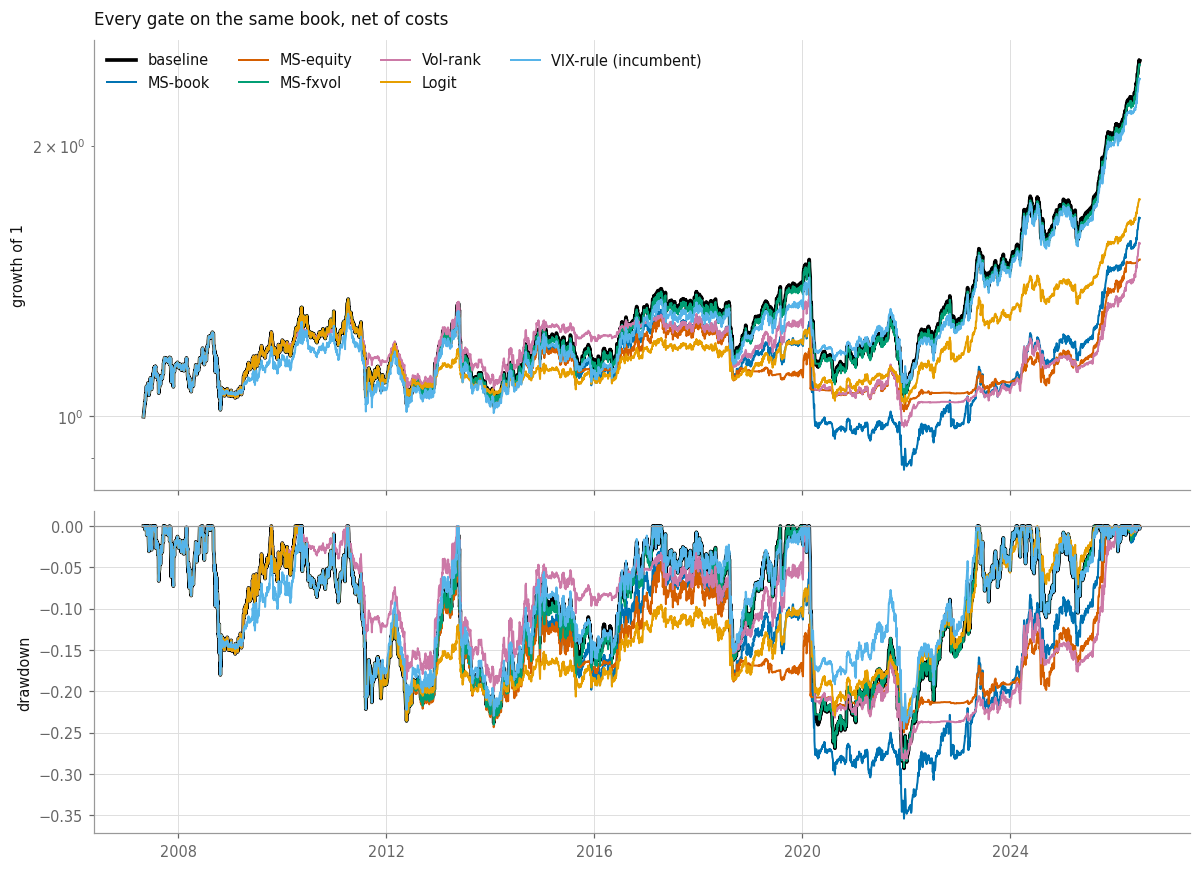

In [11]:
comparison = Comparison({k: v.net for k, v in runs.items()}, periods_per_year=252.0,
                        baseline="baseline")
comparison.save(OUT / "returns_net_daily.parquet")
Comparison({k: v.gross for k, v in runs.items()}, 252.0, "baseline").save(
    OUT / "returns_gross_daily.parquet")

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                                  gridspec_kw={"height_ratios": [1.4, 1]})
nav, drawdown = comparison.nav(), comparison.drawdown()
for (name, colour) in zip(nav.columns, PALETTE):
    width = 2.4 if name == "baseline" else 1.3
    top.plot(nav.index, nav[name], color=colour, lw=width, label=name)
    bottom.plot(drawdown.index, drawdown[name], color=colour, lw=width)
top.set_yscale("log")
top.set_ylabel("growth of 1")
top.set_title("Every gate on the same book, net of costs")
top.legend(ncol=4, loc="upper left")
bottom.set_ylabel("drawdown")
bottom.axhline(0, color="#999999", lw=0.8)
fig.tight_layout()
plt.show()

## How much of a regime gate is hindsight

This is the result I would keep if I could keep only one.

The table re-runs every model under every information set it supports, changing nothing else.
Same estimator, same data, same gate, same book. The only thing that varies is how much of the
future the model was allowed to see while forming its opinion.

In [12]:
ladder_rows = {}
for label, spec in SPECS.items():
    for information in spec["sets"]:
        result = run(exposure=linear_gate(paths[(label, information)].probability),
                     name=f"{label}|{information}")
        summary = result.summary(benchmark=None)
        net = summary.loc[[i for i in summary.index if i.endswith("_net")][0]]
        gross = summary.loc[[i for i in summary.index if i.endswith("_gross")][0]]
        ladder_rows[(label, information)] = {
            "net_sharpe": net["sharpe"], "gross_sharpe": gross["sharpe"],
            "max_dd": net["max_drawdown"], "ann_return": net["ann_return"],
            "turnover": result.turnover,
        }

ladder = pd.DataFrame(ladder_rows).T
ladder.index = pd.MultiIndex.from_tuples(ladder.index, names=["model", "information"])
ladder["vs baseline"] = ladder["net_sharpe"] - headline.loc["baseline", "net_sharpe"]
ladder.round(4)

net_sharpe  gross_sharpe  max_dd  ann_return  turnover  vs baseline
model     information                                                                     
MS-book   insample         0.5848        0.7553 -0.2295      0.0625    0.6873       0.1189
          filtered         0.5080        0.6772 -0.2534      0.0550    0.6898       0.0421
          realtime         0.3022        0.4843 -0.3541      0.0308    0.7488      -0.1637
MS-equity insample         0.5083        0.6611 -0.2134      0.0357    0.4531       0.0424
          filtered         0.3222        0.4901 -0.2022      0.0229    0.5252      -0.1437
          realtime         0.2695        0.4325 -0.2497      0.0243    0.6042      -0.1964
MS-fxvol  insample         0.5638        0.7329 -0.2457      0.0609    0.6850       0.0979
          filtered         0.5134        0.6823 -0.2580      0.0557    0.6884       0.0474
          realtime         0.4629        0.6279 -0.2918      0.0516    0.6826      -0.0030
Vol-rank  insample         0.4494        0.6129 -0.2828      0.0294    0.4268      -0.0166
          realtime         0.3115        0.4791 -0.2838      0.0257    0.5522      -0.1544
Logit     insample         0.5985        0.7705 -0.1666      0.0382    0.3998       0.1326
          realtime         0.3873        0.5482 -0.2359      0.0313    0.4876      -0.0787

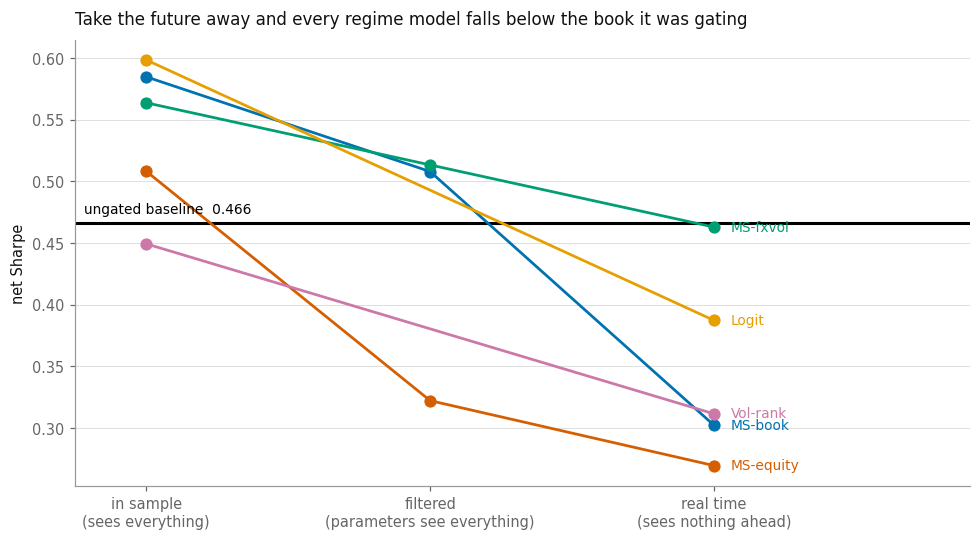

In [13]:
order = ["insample", "filtered", "realtime"]
positions = {name: i for i, name in enumerate(order)}
bar = headline.loc["baseline", "net_sharpe"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(bar, color=PALETTE[0], lw=2.0, zorder=1)
ax.annotate(f"ungated baseline  {bar:.3f}", xy=(-0.22, bar + 0.006), va="bottom", ha="left",
            fontsize=9, color=PALETTE[0])
for (label, colour) in zip(SPECS, PALETTE[1:]):
    sub = ladder.loc[label]
    x = [positions[i] for i in sub.index]
    y = sub["net_sharpe"].to_numpy(float)
    ax.plot(x, y, color=colour, marker="o", markersize=7, lw=1.8, zorder=2)
    ax.annotate(label, xy=(x[-1] + 0.06, y[-1]), va="center", fontsize=9, color=colour)
ax.set_xticks(range(3))
ax.set_xticklabels(["in sample\n(sees everything)", "filtered\n(parameters see everything)",
                    "real time\n(sees nothing ahead)"])
ax.set_xlim(-0.25, 2.9)
ax.set_ylabel("net Sharpe")
ax.set_title("Take the future away and every regime model falls below the book it was gating")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

Every line slopes down, without exception, and the ordering is the same for all five models.

In sample, four of the five beat the baseline, two of them by more than a tenth of a Sharpe
point. `Logit` reaches 0.599 against 0.466 and cuts the worst drawdown from 29% to 17%. Written
up on its own, with a plot of the probability path shaded over the drawdowns, it would look
like a good piece of work.

Filtering the states while keeping full-sample parameters removes between a third and a half of
the gain. `MS-book` falls from $+0.12$ to $+0.04$ relative to the baseline. So even the
halfway house, which many people would describe as out of sample because the state inference is
recursive, is carrying most of the advantage in its parameters.

Re-estimating the parameters honestly removes the rest, and then some. Every model ends below
the baseline. The sign of the conclusion is set by the information set, not by the model, the
data, or the gate. That is uncomfortable, because the information set is the part of a
published backtest you usually cannot check.

## A second, quieter channel of hindsight

Parameter estimation is not the only place the future gets in. The choice of specification is
another, and it does not show up in any out-of-sample test, because by the time you run the
test you have already made the choice.

The identification rule is the cleanest example I found. Below, the same estimator runs on the
same data under the same real-time information set. The only difference is which fitted state
gets called "stressed".

In [14]:
trap_rows = {}
for label, data, rules in (("MS-book", monthly, ("low_mean", "high_variance")),
                           ("MS-fxvol", fxvol_change, ("high_mean", "high_variance"))):
    for rule in rules:
        series = MarkovSwitching(information="realtime", stressed=rule,
                                 min_periods=60, refit_every=12).probabilities(data)
        result = run(exposure=linear_gate(series.probability), name=f"{label}|{rule}")
        summary = result.summary(benchmark=None)
        net = summary.loc[[i for i in summary.index if i.endswith("_net")][0]]
        trap_rows[(label, rule)] = {
            "mean P(stress)": series.probability.mean(), "net_sharpe": net["sharpe"],
            "max_dd": net["max_drawdown"], "ann_vol": net["ann_vol"],
            "avg notional": lab.average_exposure(result),
        }

trap = pd.DataFrame(trap_rows).T
trap.index = pd.MultiIndex.from_tuples(trap.index, names=["model", "stressed state rule"])
trap.round(4)

mean P(stress)  net_sharpe  max_dd  ann_vol  avg notional
model    stressed state rule                                                           
MS-book  low_mean                     0.1688      0.3022 -0.3541   0.1019        2.8183
         high_variance                0.8312      0.2962 -0.2359   0.0647        1.2122
MS-fxvol high_mean                    0.0093      0.4629 -0.2918   0.1114        3.2156
         high_variance                0.5498      0.6048 -0.2216   0.0860        1.9254

Calling the higher-variance state stressed produces a net Sharpe of 0.605 on `MS-fxvol`, which
beats the baseline by 0.14 and would be the best number in this notebook by a distance. It is
also meaningless. That configuration flags 55% of all months as stressed, which is not a
description of a crisis, and there is no story under which "the state where volatility moves
erratically in either direction" is the state a carry book should sit out.

The `MS-book` row shows the same failure from the other side. Identifying by variance flags
83% of months. The reason is visible in the fitted parameters from earlier: on short expanding
windows the high-variance state is ordinary trading, and the low-variance state is doing the
work of catching a handful of outlier months. Labelling the ordinary state "stressed" leaves
the gate de-risked almost permanently, which drops volatility from 11.2% to 6.5% and drags the
Sharpe down with it.

So one identification rule halves the book for no reason and the other clears the baseline for
no reason, and neither has anything to do with whether regimes exist. If the rule that names
the bad state is chosen after seeing the equity curve, the backtest is measuring the choice,
not the model.

## Does anything survive a sweep over the gate

The gate is a separate decision from the model, so pairing every real-time path with ten
mappings from probability to exposure asks whether the failure lies in the state estimates or
in how aggressively they were acted on. The sweep spans a linear rule at three floors, two
convex rules that only de-risk on strong conviction, and five threshold rules.

In [15]:
GATES = {
    "linear, floor 0.00": lambda p: linear_gate(p, floor=0.0),
    "linear, floor 0.25": lambda p: linear_gate(p, floor=0.25),
    "linear, floor 0.50": lambda p: linear_gate(p, floor=0.50),
    "power 2, floor 0.00": lambda p: power_gate(p, exponent=2.0, floor=0.0),
    "power 3, floor 0.00": lambda p: power_gate(p, exponent=3.0, floor=0.0),
    "cut to 0.0 above 0.50": lambda p: binary_gate(p, 0.50, floor=0.0),
    "cut to 0.5 above 0.50": lambda p: binary_gate(p, 0.50, floor=0.5),
    "cut to 0.0 above 0.70": lambda p: binary_gate(p, 0.70, floor=0.0),
    "cut to 0.5 above 0.70": lambda p: binary_gate(p, 0.70, floor=0.5),
    "cut to 0.5 above 0.90": lambda p: binary_gate(p, 0.90, floor=0.5),
}

sweep_rows = {}
for label in SPECS:
    prob = paths[(label, "realtime")].probability
    for gate_name, gate in GATES.items():
        result = run(exposure=gate(prob), name=f"{label}|{gate_name}")
        summary = result.summary(benchmark=None)
        net = summary.loc[[i for i in summary.index if i.endswith("_net")][0]]
        sweep_rows[(label, gate_name)] = {"net_sharpe": net["sharpe"],
                                          "max_dd": net["max_drawdown"],
                                          "avg notional": lab.average_exposure(result)}

sweep = pd.DataFrame(sweep_rows).T
sweep.index = pd.MultiIndex.from_tuples(sweep.index, names=["model", "gate"])
sharpe_grid = sweep["net_sharpe"].unstack(0)
sharpe_grid.round(4)

model,Logit,MS-book,MS-equity,MS-fxvol,Vol-rank
gate,,,,,
cut to 0.0 above 0.50,0.4239,0.3378,0.3066,0.4627,0.1740
cut to 0.0 above 0.70,0.4423,0.4659,0.2544,0.4627,0.2759
cut to 0.5 above 0.50,0.4622,0.4084,0.4069,0.4644,0.3464
cut to 0.5 above 0.70,0.4544,0.4659,0.3753,0.4644,0.3799
cut to 0.5 above 0.90,0.4659,0.4659,0.4175,0.4644,0.4629
"linear, floor 0.00",0.3873,0.3022,0.2695,0.4629,0.3115
"linear, floor 0.25",0.4180,0.3505,0.3359,0.4638,0.3677
"linear, floor 0.50",0.4398,0.3945,0.3904,0.4646,0.4109
"power 2, floor 0.00",0.4355,0.4049,0.3063,0.4627,0.3330


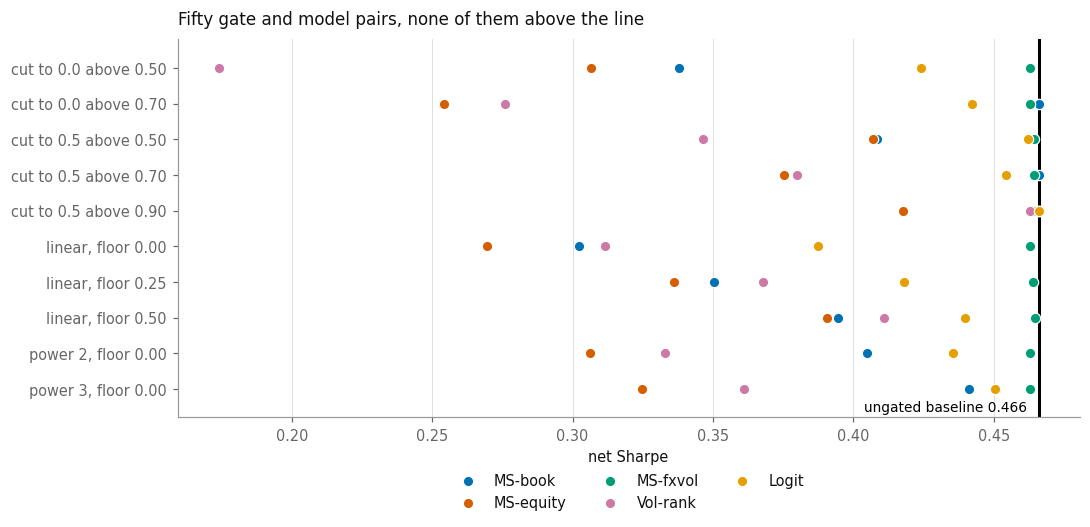

model    Logit  MS-book  MS-equity  MS-fxvol  Vol-rank
min     0.3873   0.3022     0.2544    0.4627    0.1740
median  0.4410   0.4066     0.3303    0.4634    0.3538
max     0.4659   0.4659     0.4175    0.4646    0.4629


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axvline(bar, color=PALETTE[0], lw=2.0, zorder=1)
rows = list(sharpe_grid.index)[::-1]
ax.set_ylim(-0.8, len(rows) - 0.2)
ax.annotate(f"ungated baseline {bar:.3f}", xy=(bar - 0.004, -0.7), fontsize=9,
            color=PALETTE[0], va="bottom", ha="right")
for (label, colour) in zip(SPECS, PALETTE[1:]):
    ax.scatter(sharpe_grid.loc[rows, label], range(len(rows)), s=46, color=colour,
               label=label, zorder=3, edgecolor="white", linewidth=0.8)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)
ax.set_xlabel("net Sharpe")
ax.set_title("Fifty gate and model pairs, none of them above the line")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.28))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

print(sharpe_grid.agg(["min", "median", "max"]).round(4).to_string())

Fifty combinations, and the highest value anywhere in the grid is 0.4659. It occurs four times,
three of them in the `MS-book` column and one in `Logit`, and in every case it is a threshold
the model's stress probability never actually crosses. Those cells are the baseline to four
decimal places because the gate attached to them never fires once. The optimum of this sweep is
the configuration in which the gate does nothing at all.

The pattern within each column says the same thing more gently. Sharpe rises monotonically
with the floor, from 0.302 to 0.394 on `MS-book` as the floor goes from zero to a half, and
rises again as the threshold moves from 0.50 to 0.90. Every direction that makes a gate less
active makes it better. There is no interior plateau, which is what a real effect would look
like.

The spread across gates is worth quoting next to any single cell. `MS-book` ranges from 0.302
to 0.466 depending only on how the same probabilities are acted on, and `Vol-rank` from 0.174
to 0.463.

## Is the burn-in the problem

If the real-time models fail mainly because they arm too late, shortening the burn-in should
help. It does, a little, and in a way that argues against the models rather than for them.

In [17]:
burn_rows = {}
for min_periods in (36, 60, 84):
    estimators = (
        ("MS-book", MarkovSwitching(information="realtime", stressed="low_mean",
                                    min_periods=min_periods, refit_every=12)),
        ("Logit", LogisticRegime(labels, information="realtime", ridge=1.0,
                                 min_periods=min_periods, refit_every=3)),
    )
    for label, estimator in estimators:
        series = estimator.probabilities(SPECS[label]["data"])
        result = run(exposure=linear_gate(series.probability), name=f"{label}|{min_periods}")
        summary = result.summary(benchmark=None)
        net = summary.loc[[i for i in summary.index if i.endswith("_net")][0]]
        burn_rows[(label, min_periods)] = {
            "armed from": str(series.probability.index[0].date()),
            "net_sharpe": net["sharpe"], "max_dd": net["max_drawdown"],
        }

burn = pd.DataFrame(burn_rows).T
burn.index = pd.MultiIndex.from_tuples(burn.index, names=["model", "burn-in months"])
burn

,,armed from,net_sharpe,max_dd
model,burn-in months,,,
MS-book,36,2010-05-31,0.328648,-0.349806
Logit,36,2010-07-31,0.462473,-0.180172
MS-book,60,2012-05-31,0.302178,-0.354062
Logit,60,2012-07-31,0.38727,-0.235878
MS-book,84,2014-05-31,0.285272,-0.379143
Logit,84,2014-07-31,0.380303,-0.23808


Three years of burn-in arms the models in 2010 and lifts `Logit` to 0.462, within a whisker of
the baseline, and `MS-book` to 0.329. Seven years pushes them to 2014 and drops both. So
shorter is better, monotonically, across the range.

The natural reading is that more live history helps. The less flattering reading, which I think
is the right one, is that shorter burn-in simply means fewer months of gating, and a gate that
does less does better. It is the sweep result again in a different costume. Either way, none of
the three arms in time for 2008, and the best of them still only draws level with doing
nothing.

## The drawdown argument, and why it does not hold

There is a defence available at this point, and it is a reasonable one. Sharpe is not why
anyone runs a crisis gate. You run it so the bad quarter is survivable, and the headline table
does show `Logit` cutting the worst drawdown from 29.3% to 23.6% and the VIX rule to 24.5%.

The problem is that all of these books hold less risk than the baseline, and a smaller position
has a smaller drawdown whether or not it was ever timed well. Separating the two means putting
every book on the same realised volatility and looking again. That rescaling is not a portfolio
anyone could run, since the scale factor is a full-sample number, but it isolates the question
of whether the risk was held at better moments.

In [18]:
rescaled = Comparison(comparison.rescaled(), 252.0, "baseline").table()
rescaled = rescaled[["mean", "volatility", "sharpe", "max_drawdown"]]
observed = headline[["ann_vol", "max_dd"]].rename(
    columns={"ann_vol": "vol as run", "max_dd": "drawdown as run"})
observed.join(rescaled[["max_drawdown"]].rename(
    columns={"max_drawdown": "drawdown at equal vol"})).round(4)

,vol as run,drawdown as run,drawdown at equal vol
baseline,0.1119,-0.2932,-0.2932
MS-book,0.1019,-0.3541,-0.3852
MS-equity,0.0902,-0.2497,-0.3091
MS-fxvol,0.1114,-0.2918,-0.2930
Vol-rank,0.0826,-0.2838,-0.3664
Logit,0.0807,-0.2359,-0.3185
VIX-rule (incumbent),0.1055,-0.2450,-0.2582


At equal volatility the drawdown improvement does not survive. `Logit` goes from 23.6% to
31.9%, worse than the baseline's 29.3%. `MS-book` goes to 38.5% and `Vol-rank` to 36.6%. The
apparent tail protection was the de-leveraging, and once you give the money back to the book to
maintain the same risk, these gates have you carrying it into worse moments than the ungated
version would have.

One book breaks the pattern. The incumbent VIX rule holds 25.8% at equal volatility against the
baseline's 29.3%, with Sharpe essentially unchanged at 0.4653. It is the only construction in
this notebook that improves anything after the risk budget is held fixed, and what it improves
is the shape of the tail rather than the return.

The statistical picture is consistent with all of this. The active return of each gate against
the baseline, with Newey-West standard errors, is negative for every model. It is significantly
negative for the four that take real positions, with $t$ statistics between $-2$ and $-4$, and
indistinguishable from zero for the two that barely trade. Nothing anywhere is significantly
positive.

In [19]:
relative = comparison.relative(hac=HAC(lags=10))
relative[["sharpe", "sharpe_delta", "active_return", "tracking_error", "info_ratio",
          "active_t", "corr_to_baseline"]].round(4)

,sharpe,sharpe_delta,active_return,tracking_error,info_ratio,active_t,corr_to_baseline
baseline,0.4659,0.0000,0.0000,0.0000,NaN,NaN,1.0000
MS-book,0.3022,-0.1637,-0.0214,0.0233,-0.9182,-3.9819,0.9807
MS-equity,0.2695,-0.1964,-0.0278,0.0489,-0.5691,-2.3701,0.9049
MS-fxvol,0.4629,-0.0030,-0.0006,0.0044,-0.1304,-0.7364,0.9992
Vol-rank,0.3115,-0.1544,-0.0264,0.0482,-0.5481,-2.5130,0.9209
Logit,0.3873,-0.0787,-0.0209,0.0436,-0.4794,-2.0866,0.9488
VIX-rule (incumbent),0.4653,-0.0007,-0.0030,0.0215,-0.1412,-0.6079,0.9821


In [20]:
episodes = comparison.subperiods(lab.EPISODES, field="sharpe")
episodes.round(3)

,baseline,MS-book,MS-equity,MS-fxvol,Vol-rank,Logit,VIX-rule (incumbent)
pre-crisis 2007-08,1.438,1.438,1.438,1.438,1.438,1.438,1.438
GFC 2008-09,-0.430,-0.430,-0.430,-0.430,-0.430,-0.430,-0.812
recovery 2009-11,0.345,0.345,0.345,0.345,0.520,0.345,0.345
euro crisis 2011-12,-0.224,-0.281,-0.286,-0.241,-0.278,-0.504,-0.135
taper + EM 2013-16,0.293,0.228,0.180,0.285,0.230,0.265,0.284
calm 2017-19,0.230,-0.119,-0.352,0.229,0.030,0.125,0.178
covid 2020,-1.256,-1.843,-0.702,-1.287,-1.669,-1.329,-1.148
tightening 2021-23,0.704,0.408,0.201,0.700,0.031,0.810,0.623
recent 2024-26,1.993,2.034,1.658,1.994,2.063,1.935,1.924


The episode table shows why single-crisis anecdotes are so persuasive and so useless. The first
three rows are identical across every column because the real-time models had not started yet.
After that the gates trade wins for losses with no pattern: `MS-equity` softens COVID, going
$-0.70$ against the baseline's $-1.26$, then gives it all back through 2021 to 2023 at 0.20
against 0.70. `Logit` is the best book of any through the tightening period and the worst
through the euro crisis.

Pick your episode and you can support any conclusion you like, which is a good reason to
distrust anyone who leads with one.

## Where this leaves the book

Regime gating does not improve this carry book on this sample, and the failure is not marginal.
Five models covering three quite different families all land below the ungated baseline, the
best gate in a fifty-cell sweep is the one that never fires, and the drawdown protection
disappears the moment you control for how much risk was actually held.

The more useful finding is *why* published versions of this look better. Four of the five
models beat the baseline in sample and one of them by a lot, so the difference between a
positive and a negative write-up here is entirely the information set. Filtering the states
while leaving parameters fitted on the full sample, which is a very easy thing to do without
noticing, recovers about half of the illusion. A second and quieter channel runs through
specification: choosing which fitted state to call stressed swings `MS-fxvol` from 0.463 to
0.605, and that choice leaves no trace in any out-of-sample statistic.

Two things are worth carrying forward. The first is a data constraint with a price attached.
The shared panel starts in 2007, a regime model needs three to seven years of burn-in, and so
no honest gate in this notebook was armed during the 2008 unwind. Risk-factor history back to
the 1990s would let a model face a crisis it had not already been fitted on, and until that
exists any claim about regime models and carry crashes rests on two events, one of which is
inside the training window.

The second is that the simple rule already in the repository is the only construction that
improves anything. Half the exposure when FX-relevant volatility is in the top fifth of its
trailing three years, and you keep the baseline's Sharpe while cutting the equal-risk drawdown
from 29.3% to 25.8%. It has one parameter, it needs no estimation, and it arms from the first
day there is enough history to rank against. That is a smaller claim than a Markov chain, and
on this evidence it is the one I would defend.

In [21]:
summary_note = pd.DataFrame({
    "net sharpe": headline["net_sharpe"],
    "drawdown as run": headline["max_dd"],
    "drawdown at equal vol": rescaled["max_drawdown"],
    "avg notional": headline["avg notional"],
}).round(4)
summary_note.to_csv(OUT / "notebook_summary.csv")
summary_note

,net sharpe,drawdown as run,drawdown at equal vol,avg notional
baseline,0.4659,-0.2932,-0.2932,3.2318
MS-book,0.3022,-0.3541,-0.3852,2.8183
MS-equity,0.2695,-0.2497,-0.3091,2.3299
MS-fxvol,0.4629,-0.2918,-0.2930,3.2156
Vol-rank,0.3115,-0.2838,-0.3664,2.1695
Logit,0.3873,-0.2359,-0.3185,2.1383
VIX-rule (incumbent),0.4653,-0.2450,-0.2582,2.9860
